<a href="https://colab.research.google.com/github/mohitsinghuk/Anomaly_Detection/blob/main/anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.metrics import recall_score, classification_report, auc, roc_curve
from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.preprocessing import StandardScaler
from pylab import rcParams
from keras.models import Model, load_model
from keras.layers import Input, Dense
from keras.callbacks import ModelCheckpoint, TensorBoard
from keras import regularizers
import io
warnings.filterwarnings('ignore')



In [ ]:
from google.colab import files
uploaded1 = files.upload()

Saving shuttle-unsupervised-ad.csv to shuttle-unsupervised-ad (2).csv


In [ ]:
file_name1 = "shuttle-unsupervised-ad.csv"

In [ ]:
df = pd.read_csv(file_name1)

In [ ]:
data = df

In [ ]:
df = pd.read_csv("shuttle-unsupervised-ad.csv")
df.head()

,108.0,3.0,109.0,0.0,72.0,7.0,1.0,36.0,36.0.1,o
0,81.0,0.0,84.0,0.0,-14.0,-2.0,4.0,100.0,96.0,o
1,81.0,0.0,84.0,0.0,-20.0,16.0,4.0,105.0,102.0,o
2,76.0,-1.0,81.0,0.0,-42.0,-3.0,5.0,125.0,120.0,o
3,105.0,0.0,107.0,2.0,70.0,0.0,1.0,37.0,36.0,o
4,79.0,0.0,83.0,-1.0,-40.0,7.0,4.0,124.0,120.0,o


In [ ]:
print(data.head())
print(data.info())
print(data.describe())


   108.0  3.0  109.0  0.0  72.0   7.0  1.0   36.0  36.0.1  o
0   81.0  0.0   84.0  0.0 -14.0  -2.0  4.0  100.0    96.0  o
1   81.0  0.0   84.0  0.0 -20.0  16.0  4.0  105.0   102.0  o
2   76.0 -1.0   81.0  0.0 -42.0  -3.0  5.0  125.0   120.0  o
3  105.0  0.0  107.0  2.0  70.0   0.0  1.0   37.0    36.0  o
4   79.0  0.0   83.0 -1.0 -40.0   7.0  4.0  124.0   120.0  o
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46463 entries, 0 to 46462
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   108.0   46463 non-null  float64
 1   3.0     46463 non-null  float64
 2   109.0   46463 non-null  float64
 3   0.0     46463 non-null  float64
 4   72.0    46463 non-null  float64
 5   7.0     46463 non-null  float64
 6   1.0     46463 non-null  float64
 7   36.0    46463 non-null  float64
 8   36.0.1  46463 non-null  float64
 9   o       46463 non-null  object 
dtypes: float64(9), object(1)
memory usage: 3.5+ MB
None
              108.0     

In [ ]:
data.replace('o', 0, inplace=True)
data.replace('n', 1, inplace= True)
data.head()

,108.0,3.0,109.0,0.0,72.0,7.0,1.0,36.0,36.0.1,o
0,81.0,0.0,84.0,0.0,-14.0,-2.0,4.0,100.0,96.0,0
1,81.0,0.0,84.0,0.0,-20.0,16.0,4.0,105.0,102.0,0
2,76.0,-1.0,81.0,0.0,-42.0,-3.0,5.0,125.0,120.0,0
3,105.0,0.0,107.0,2.0,70.0,0.0,1.0,37.0,36.0,0
4,79.0,0.0,83.0,-1.0,-40.0,7.0,4.0,124.0,120.0,0


In [ ]:
# Create custom headers as 'A', 'B', 'C', etc.
column_names = [chr(i) for i in range(65, 65 + data.shape[1])]  # Creating column names like A, B, C...
data.columns = column_names

# Preview the data with new headers
print(data.head())

       A    B      C    D     E     F    G      H      I  J
0   81.0  0.0   84.0  0.0 -14.0  -2.0  4.0  100.0   96.0  0
1   81.0  0.0   84.0  0.0 -20.0  16.0  4.0  105.0  102.0  0
2   76.0 -1.0   81.0  0.0 -42.0  -3.0  5.0  125.0  120.0  0
3  105.0  0.0  107.0  2.0  70.0   0.0  1.0   37.0   36.0  0
4   79.0  0.0   83.0 -1.0 -40.0   7.0  4.0  124.0  120.0  0


In [ ]:
# Check the first few rows of the dataset
print(data.head())

# Check the structure and summary of the dataset
print(data.info())

# Check the column names and data types
print(data.columns)


       A    B      C    D     E     F    G      H      I  J
0   81.0  0.0   84.0  0.0 -14.0  -2.0  4.0  100.0   96.0  0
1   81.0  0.0   84.0  0.0 -20.0  16.0  4.0  105.0  102.0  0
2   76.0 -1.0   81.0  0.0 -42.0  -3.0  5.0  125.0  120.0  0
3  105.0  0.0  107.0  2.0  70.0   0.0  1.0   37.0   36.0  0
4   79.0  0.0   83.0 -1.0 -40.0   7.0  4.0  124.0  120.0  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46463 entries, 0 to 46462
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       46463 non-null  float64
 1   B       46463 non-null  float64
 2   C       46463 non-null  float64
 3   D       46463 non-null  float64
 4   E       46463 non-null  float64
 5   F       46463 non-null  float64
 6   G       46463 non-null  float64
 7   H       46463 non-null  float64
 8   I       46463 non-null  float64
 9   J       46463 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 3.5 MB
None
Index(['A', 'B', 'C', 'D', 'E', 

In [ ]:
data.J.unique()

array([0, 1])

In [ ]:
data.replace('o', 0, inplace=True)
data.replace('n', 1, inplace= True)
data.head()

,A,B,C,D,E,F,G,H,I,J
0,81.0,0.0,84.0,0.0,-14.0,-2.0,4.0,100.0,96.0,0
1,81.0,0.0,84.0,0.0,-20.0,16.0,4.0,105.0,102.0,0
2,76.0,-1.0,81.0,0.0,-42.0,-3.0,5.0,125.0,120.0,0
3,105.0,0.0,107.0,2.0,70.0,0.0,1.0,37.0,36.0,0
4,79.0,0.0,83.0,-1.0,-40.0,7.0,4.0,124.0,120.0,0


In [ ]:
data.tail()

,A,B,C,D,E,F,G,H,I,J
46458,46.0,5.0,78.0,0.0,46.0,5.0,32.0,32.0,0.0,1
46459,37.0,0.0,79.0,-1.0,10.0,3.0,43.0,69.0,26.0,1
46460,48.0,0.0,78.0,3.0,46.0,0.0,30.0,32.0,2.0,1
46461,41.0,0.0,79.0,0.0,38.0,-25.0,38.0,40.0,2.0,1
46462,40.0,-3.0,100.0,0.0,38.0,0.0,61.0,62.0,2.0,1


In [ ]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Check the percentage of missing values
missing_percentage = (data.isnull().sum() / len(data)) * 100
print("Percentage of missing values:\n", missing_percentage)


Missing values in each column:
 A    0
B    0
C    0
D    0
E    0
F    0
G    0
H    0
I    0
J    0
dtype: int64
Percentage of missing values:
 A    0.0
B    0.0
C    0.0
D    0.0
E    0.0
F    0.0
G    0.0
H    0.0
I    0.0
J    0.0
dtype: float64


In [ ]:
# Summary statistics of the data
summary_stats = data.describe()
print(summary_stats)


                  A             B             C             D             E  \
count  46463.000000  46463.000000  46463.000000  46463.000000  46463.000000   
mean      44.774121     -0.712589     84.833588      0.279298     38.652046   
std        8.748582     44.218479      8.730549     37.317605     15.901924   
min       27.000000  -4475.000000     21.000000  -3939.000000   -188.000000   
25%       37.000000      0.000000     79.000000      0.000000     34.000000   
50%       43.000000      0.000000     83.000000      0.000000     42.000000   
75%       49.000000      0.000000     87.000000      0.000000     46.000000   
max      123.000000   1963.000000    149.000000   3830.000000    436.000000   

                  F             G             H             I             J  
count  46463.000000  46463.000000  46463.000000  46463.000000  46463.000000  
mean       2.289607     40.071175     46.180638      6.299249      0.981125  
std      177.520265     10.968076     17.052585     15

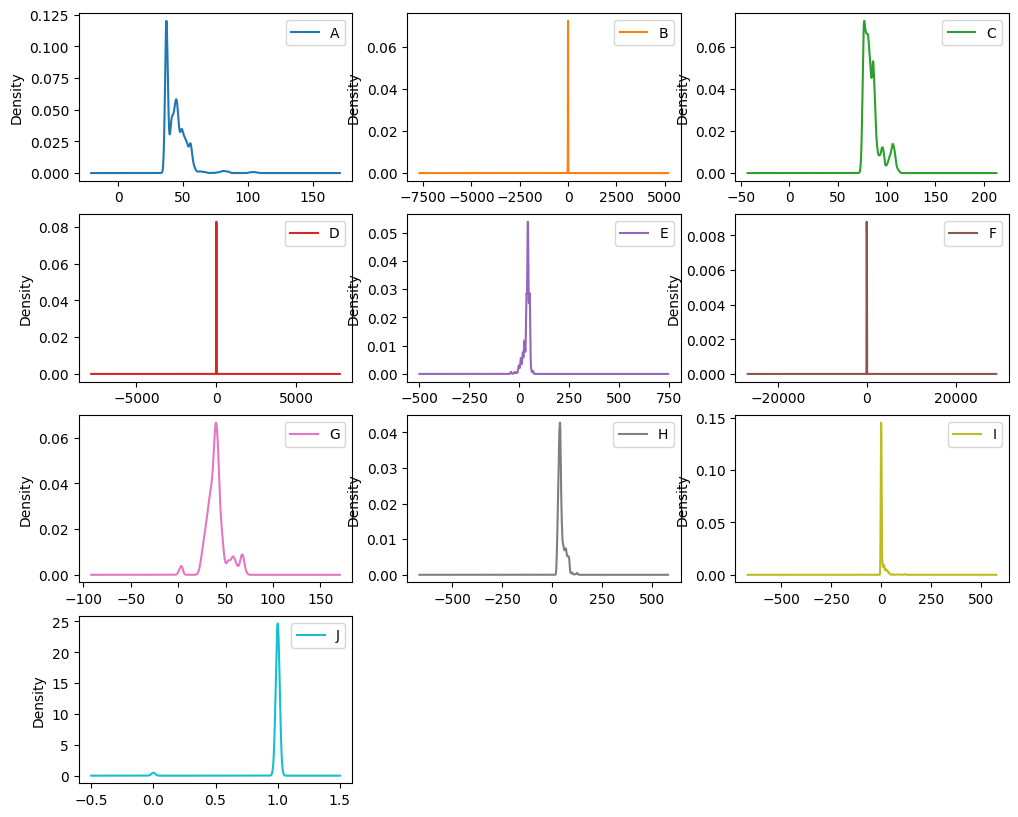

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Determine the number of features/columns
num_features = data.shape[1]

# Calculate the number of rows and columns for the layout
cols = 3  # You can change this number based on how many plots you want per row
rows = math.ceil(num_features / cols)

# Plot density plots for each feature
data.plot(kind='density', subplots=True, layout=(rows, cols), sharex=False, figsize=(12, 10))
plt.show()



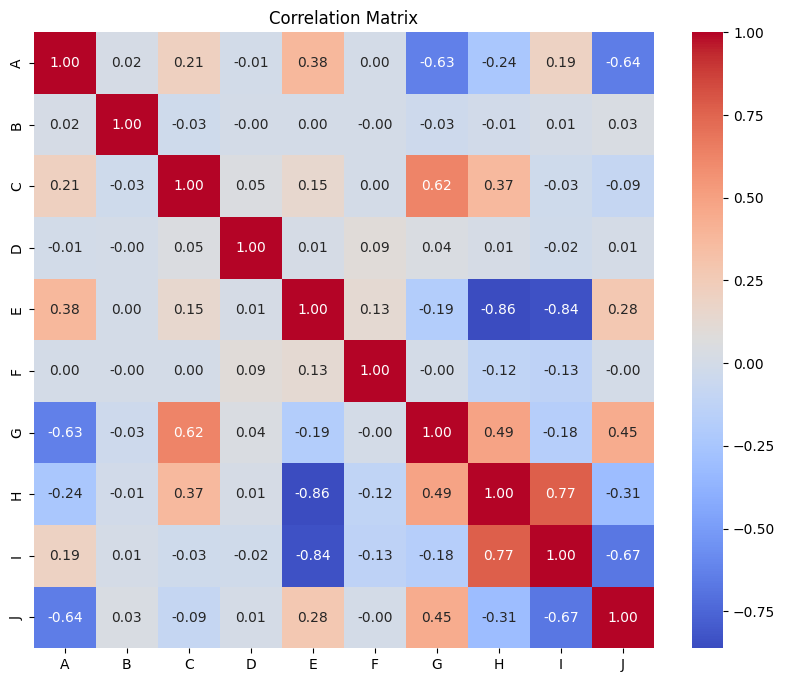

In [ ]:
# Calculate the correlation matrix
corr_matrix = data.corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


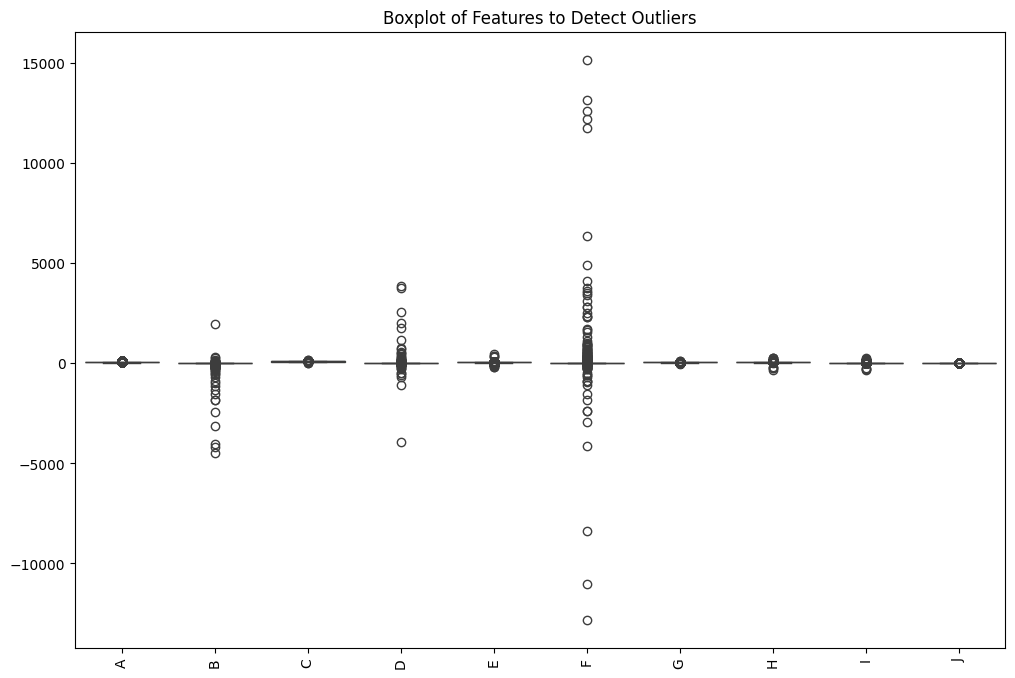

In [ ]:
# Boxplots to detect outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=data)
plt.title("Boxplot of Features to Detect Outliers")
plt.xticks(rotation=90)
plt.show()


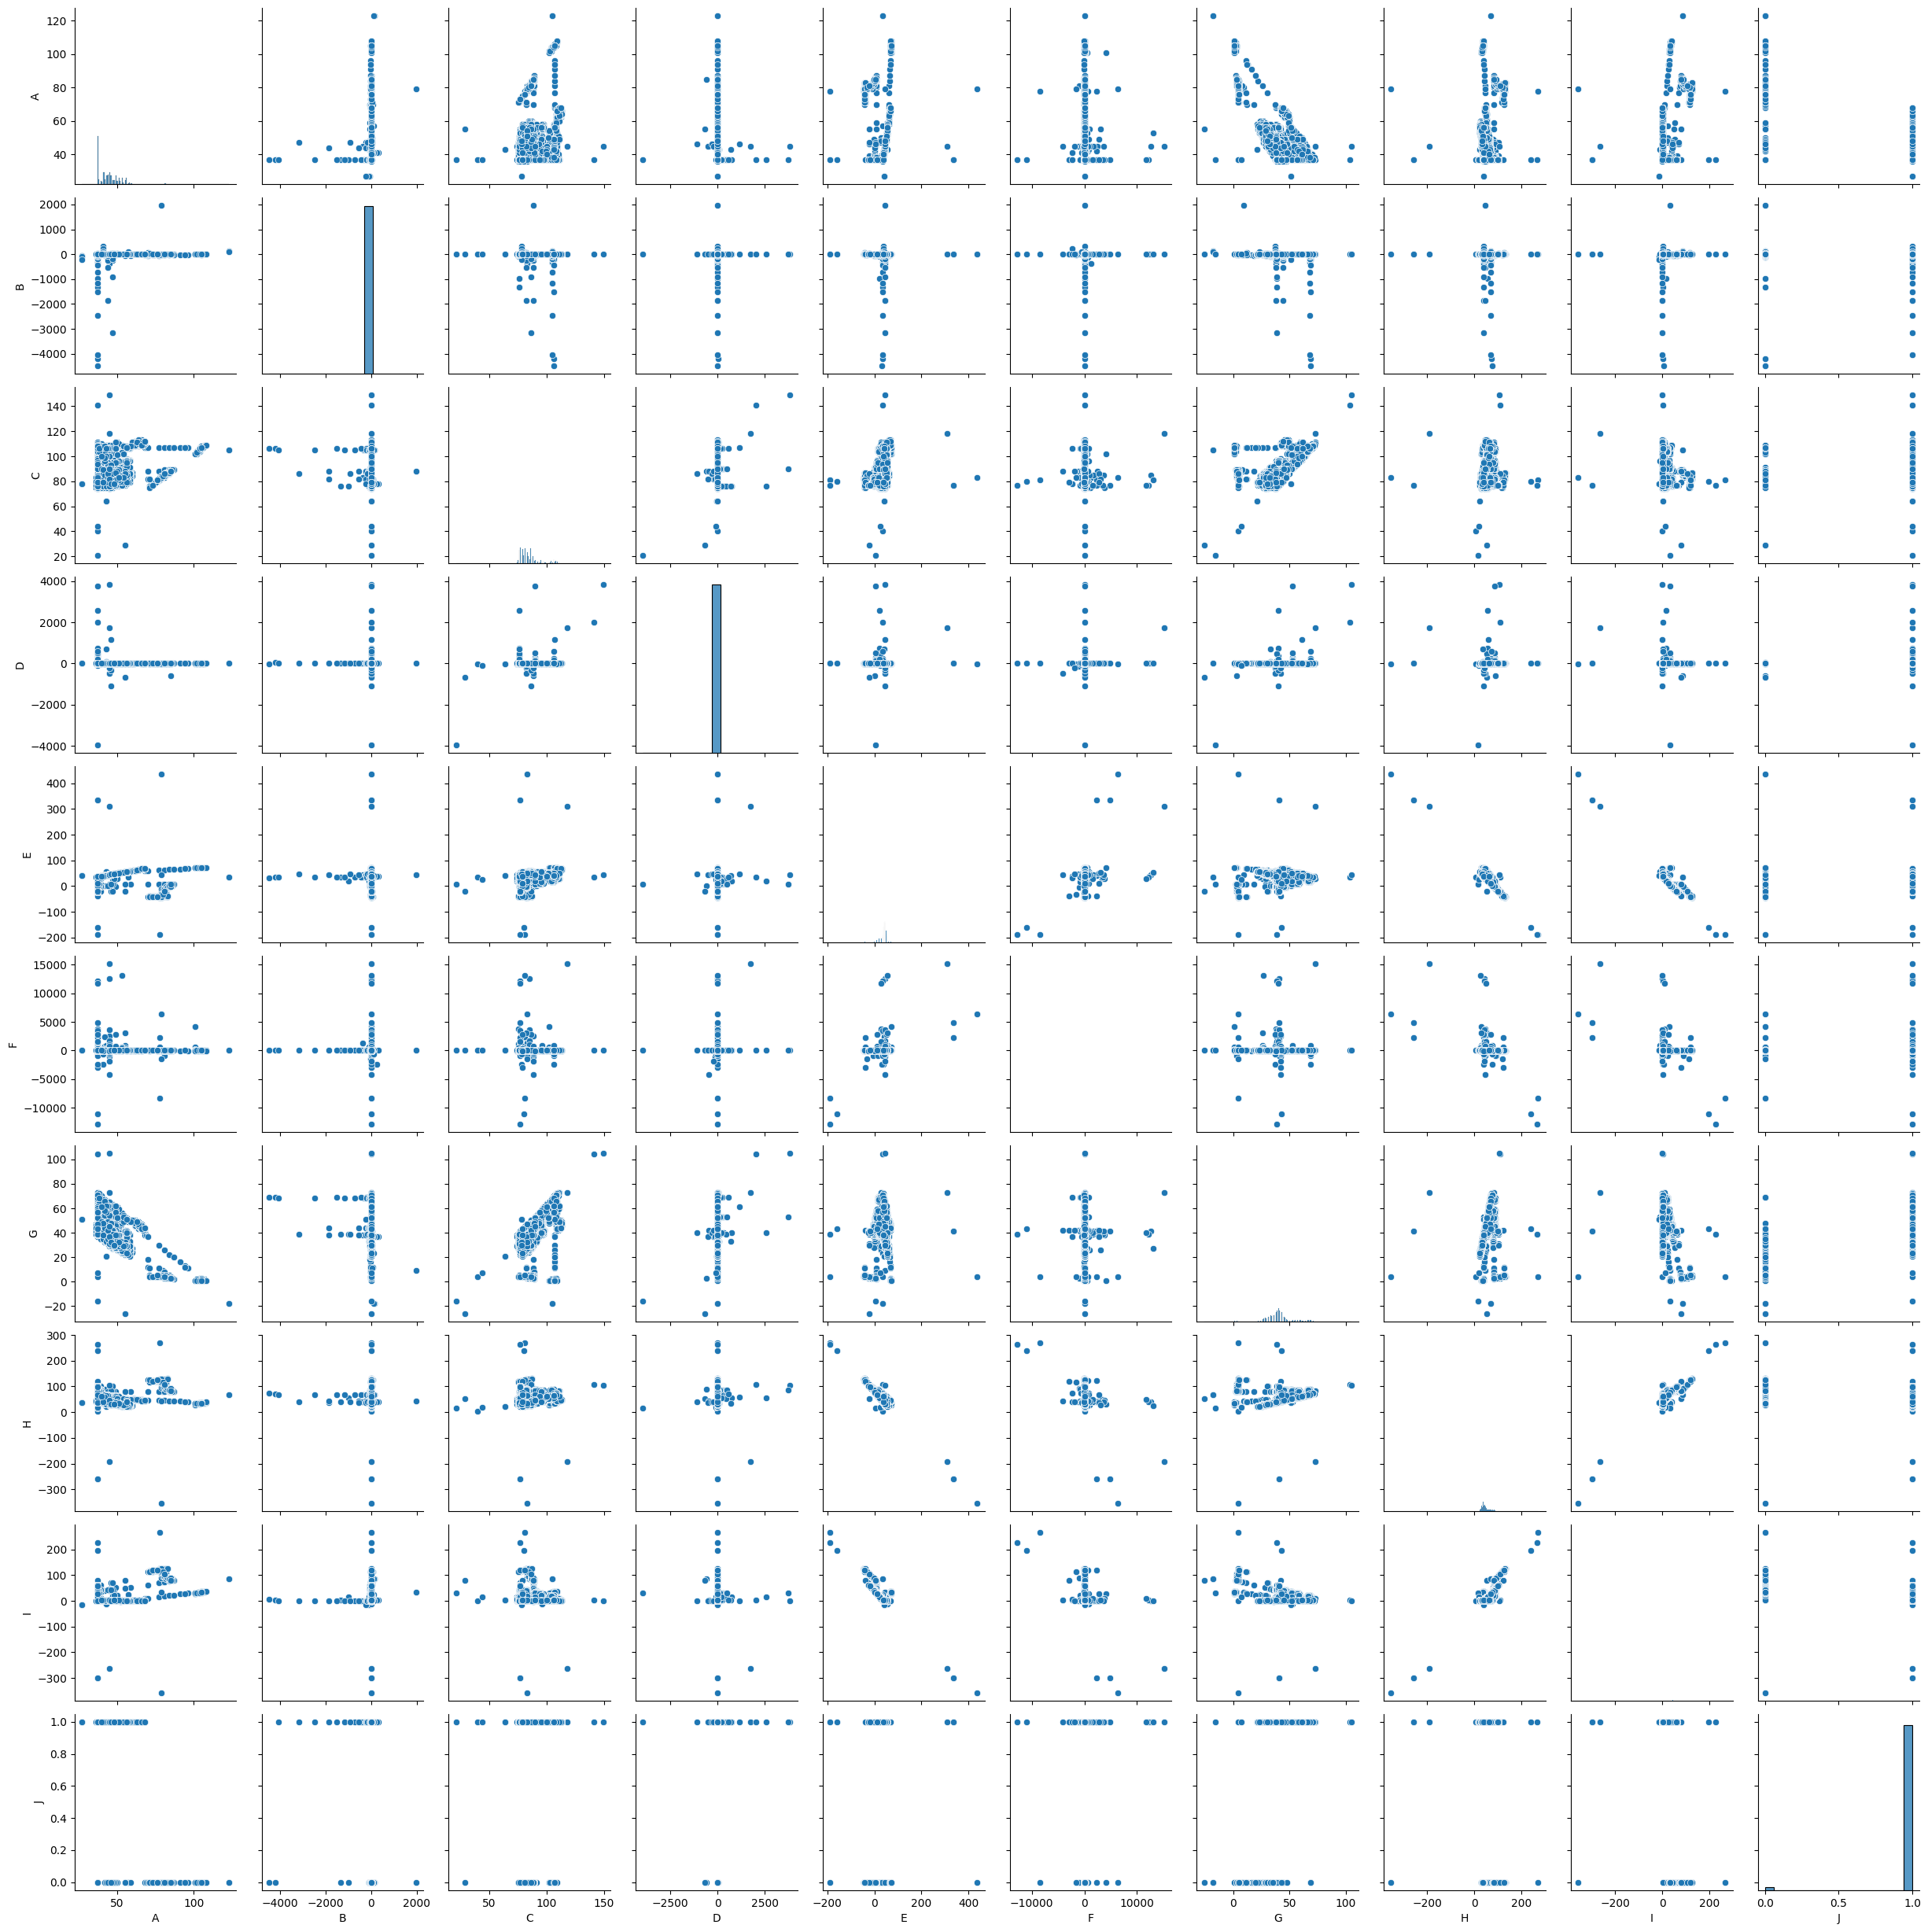

In [ ]:
# Pairplot to visualize relationships between features
sns.pairplot(data)
plt.show()


In [ ]:
# Plot the distribution of a target variable if applicable
if 'class' in data.columns:
    sns.countplot(x='class', data=data)
    plt.title("Class Distribution")
    plt.show()


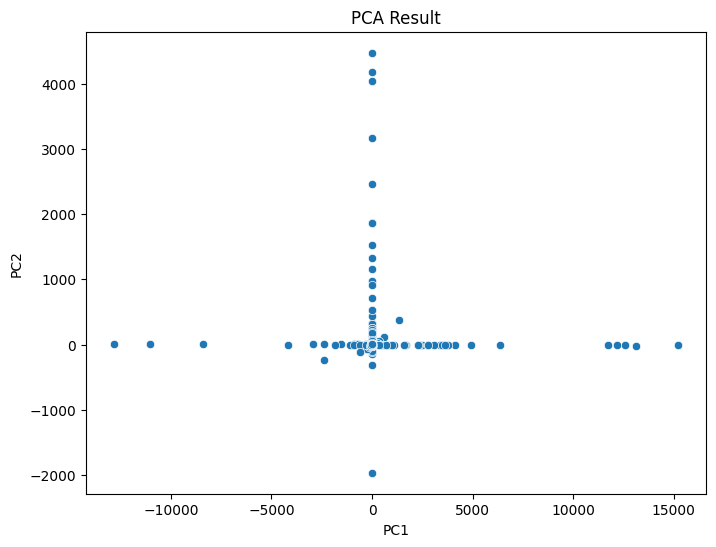

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the dimensionality
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data)

# Create a dataframe for PCA result
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])

# Plot the PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df)
plt.title("PCA Result")
plt.show()


# EDA done


In [ ]:
!pip install syft
import torch as th
import syft as sy

# Connect to a PySyft Grid node (you would need a running PyGrid instance)
# node = sy.VirtualMachine(name="my_vm")


# No TorchHook needed, use PySyft’s Virtual Machine to manage computation
# You can use Virtual Machines or deploy to remote nodes using PyGrid

print("Using PySyft v0.6.x")


Using PySyft v0.6.x


In [ ]:
import torch as th
import torch.nn as nn
import torch.optim as optim

# Define a simple neural network

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(10, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = th.relu(self.fc1(x))
        return self.fc2(x)

# Initialize the model
model = Net()


In [ ]:
def train(data, target, model, optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(data)
    loss_fn = nn.MSELoss()
    loss = loss_fn(output, target)
    loss.backward()
    optimizer.step()
    return model.state_dict(), loss.item()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Extract features (assuming the last column is the target as mentioned earlier)
X = data.iloc[:, :-1].values  # Features

# Normalize the features using Min-Max scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

# Create DataLoader for training and validation
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, X_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_val_tensor, X_val_tensor), batch_size=batch_size, shuffle=False)

# Define the Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, encoding_dim),
            nn.Tanh(),
            nn.Linear(encoding_dim, encoding_dim // 2),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim // 2, encoding_dim),
            nn.Tanh(),
            nn.Linear(encoding_dim, input_dim),
            nn.ReLU()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Initialize the autoencoder
input_dim = X_train.shape[1]
encoding_dim = 14  # Adjust this as needed
autoencoder = Autoencoder(input_dim=input_dim, encoding_dim=encoding_dim)

# Set up the optimizer and loss function
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)  # Adjust learning rate as needed
criterion = nn.MSELoss()

# Training loop
nb_epoch = 50
best_loss = float('inf')
best_model_path = "autoencoder_edge.pth"

for epoch in range(nb_epoch):
    autoencoder.train()
    running_loss = 0.0
    for data, _ in train_loader:
        optimizer.zero_grad()  # Zero the parameter gradients
        outputs = autoencoder(data)
        loss = criterion(outputs, data)
        loss.backward()
        optimizer.step()  # Update weights
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader:
            outputs = autoencoder(data)
            loss = criterion(outputs, data)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)

    print(f'Epoch [{epoch+1}/{nb_epoch}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')

    # Save the model if it's the best so far
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(autoencoder.state_dict(), best_model_path)
        print(f"Best model saved with validation loss: {best_loss:.4f}")

# To load the best model later
# autoencoder.load_state_dict(torch.load(best_model_path))

# Function to calculate reconstruction error for each sample
def get_reconstruction_errors(model, data_loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for data, _ in data_loader:
            outputs = model(data)
            loss = torch.mean((outputs - data) ** 2, dim=1)  # Reconstruction error
            errors.extend(loss.cpu().numpy())
    return errors

# Set the threshold for classification (anomalies)
def classify_reconstruction_errors(errors, threshold):
    return [1 if e > threshold else 0 for e in errors]  # 1 means anomaly, 0 means normal

# Example usage after training
train_errors = get_reconstruction_errors(autoencoder, train_loader)
test_errors = get_reconstruction_errors(autoencoder, test_loader)

# Set a threshold for anomaly detection (e.g., mean + 2 * std of training errors)
threshold = np.mean(train_errors) + 2 * np.std(train_errors)

# Get predicted labels for validation set (1 = anomaly, 0 = normal)
y_val_pred = classify_reconstruction_errors(test_errors, threshold)

# Assuming you have the true labels for the validation set (0 = normal, 1 = anomaly)
y_val_true = [0] * len(test_errors)  # Replace this with actual labels if available

# Calculate accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred)
recall = recall_score(y_val_true, y_val_pred)
f1 = f1_score(y_val_true, y_val_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Epoch [1/50], Train Loss: 0.1458, Validation Loss: 0.1391
Best model saved with validation loss: 0.1391
Epoch [2/50], Train Loss: 0.1390, Validation Loss: 0.1386
Best model saved with validation loss: 0.1386
Epoch [3/50], Train Loss: 0.1376, Validation Loss: 0.1372
Best model saved with validation loss: 0.1372
Epoch [4/50], Train Loss: 0.1372, Validation Loss: 0.1372
Best model saved with validation loss: 0.1372
Epoch [5/50], Train Loss: 0.1372, Validation Loss: 0.1371
Best model saved with validation loss: 0.1371
Epoch [6/50], Train Loss: 0.1372, Validation Loss: 0.1371
Best model saved with validation loss: 0.1371
Epoch [7/50], Train Loss: 0.1372, Validation Loss: 0.1371
Best model saved with validation loss: 0.1371
Epoch [8/50], Train Loss: 0.1372, Validation Loss: 0.1371
Best model saved with validation loss: 0.1371
Epoch [9/50], Train Loss: 0.1372, Validation Loss: 0.1371
Best model saved with validation loss: 0.1371
Epoch [10/50], Train Loss: 0.1372, Validation Loss: 0.1371
Best 

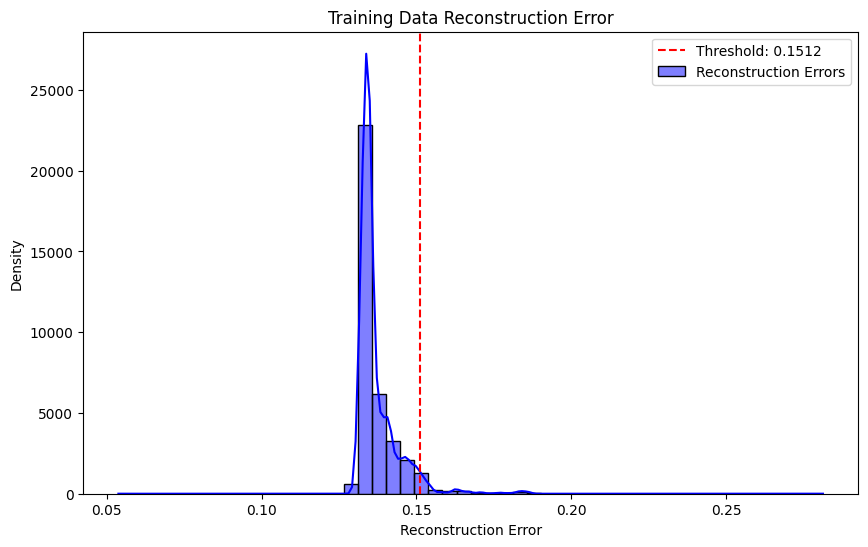

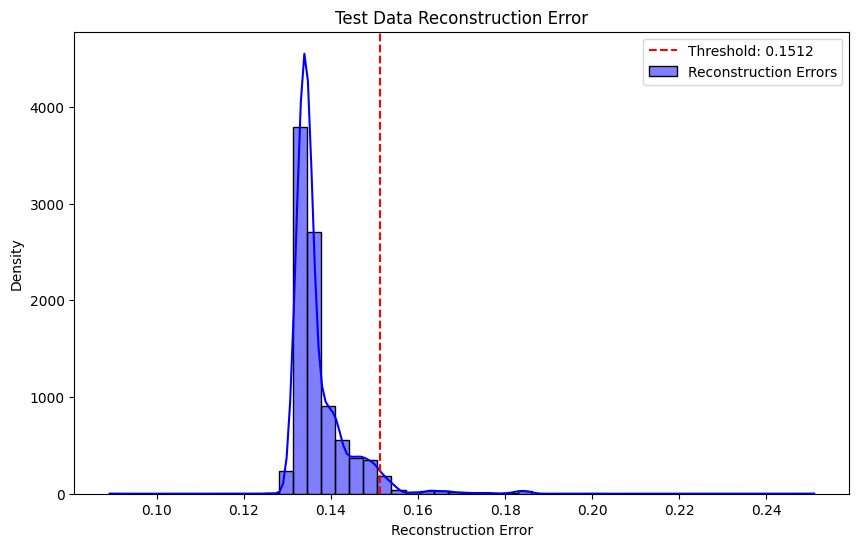

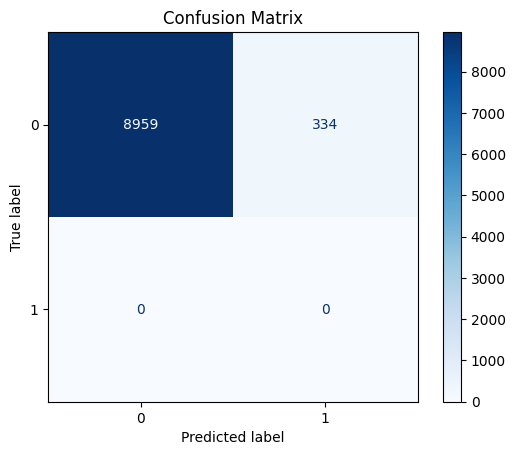

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to plot the reconstruction error distribution
def plot_reconstruction_error(errors, threshold, title='Reconstruction Error Distribution'):
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, bins=50, kde=True, color='blue', label='Reconstruction Errors')
    plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.4f}')
    plt.title(title)
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Plot reconstruction error for training data
plot_reconstruction_error(train_errors, threshold, title='Training Data Reconstruction Error')

# Plot reconstruction error for test data
plot_reconstruction_error(test_errors, threshold, title='Test Data Reconstruction Error')

# Function to plot training and validation loss over epochs
def plot_loss_curve(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.show()

# Example usage after training loop (assuming you store the losses during training)
# train_losses and val_losses would need to be tracked in the training loop
# plot_loss_curve(train_losses, val_losses)

# Function to visualize confusion matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

# Assuming you have y_val_true and y_val_pred from the previous step
plot_confusion_matrix(y_val_true, y_val_pred)
